# 03 — Forecasting & Guardrails Walkthrough

**Module:** `msmt.forecasting` &nbsp;•&nbsp; **Companion to:** *Main Street Marketplace*, Articles 3 & 4 — *Forecasting Demand for Small Sellers* and *Guardrails: When to Trust the Forecast*.

This notebook is in two parts. **Section 1** walks through the toolkit's approach to picking a forecasting method based on the demand pattern of the SKU — a counselor doesn't have to know what an exponential smoother is to use it. **Section 2** simulates a *regime change* — the kind of real-world event that breaks otherwise-good forecasts — and shows the five guardrails firing in response.

> **Note on the data.** Everything generated below is **synthetic**, produced by `msmt.data.generate_seller_data`. The same code runs on a real seller catalog by replacing the synthetic DataFrame with the seller's own export.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from msmt.data import generate_seller_data, PATTERNS
from msmt.forecasting import (
    auto_select_method,
    run_forecast,
    run_guardrails,
    is_prophet_available,
    naive_forecast,
    seasonal_naive_forecast,
    moving_average_forecast,
    ses_forecast,
    holts_forecast,
    holt_winters_forecast,
    croston_forecast,
    prophet_forecast,
)

print(f'Prophet available: {is_prophet_available()}')
seller_df = generate_seller_data(n_skus=50, n_days=365, seed=42)
print(f"Catalog: {len(seller_df):,} rows, "
      f"{seller_df['sku_id'].nunique()} SKUs, "
      f"{seller_df['date'].min().date()} \u2192 "
      f"{seller_df['date'].max().date()}")


Importing plotly failed. Interactive plots will not work.


Prophet available: True
Catalog: 18,250 rows, 50 SKUs, 2025-01-01 → 2025-12-31


# Section 1 — Method comparison (Article 3)

Different demand patterns deserve different forecasters. A method that shines on a smooth, steady SKU will badly under-buffer a holiday-spike SKU and produce nonsense for an intermittent one. The toolkit's job is to pick the right method automatically; this section opens the box and shows the picks side by side.

**Selection rules** (matching Article 3):

| Pattern | History | Method | Why |
|---|---|---|---|
| any | < 56 days | moving_average | not enough history for anything else |
| new_sku | any | moving_average | same — treat as low-information |
| intermittent | any | croston | model size and incidence separately |
| holiday_spike | ≥ 365 days | prophet | full-year history captures the cycle |
| holiday_spike | < 365 days | holt_winters | weekly cycle is the best signal we have |
| weekly_seasonal | any | holt_winters | level + trend + 7-day cycle |
| smooth | any | ses | level only; add nothing the data doesn't ask for |

### Pick one representative SKU per pattern

We'll use the synthetic `pattern` ground-truth to pick a representative, so that every pattern is exercised once. In a real catalog you wouldn't have this column — the toolkit's classifier produces it.

In [2]:
representatives = {}
for p in PATTERNS:
    sku_ids = seller_df[seller_df['pattern'] == p]['sku_id'].unique()
    if len(sku_ids):
        representatives[p] = sku_ids[0]
representatives


{'smooth': 'SKU-SM-0001',
 'weekly_seasonal': 'SKU-WS-0019',
 'holiday_spike': 'SKU-HS-0032',
 'intermittent': 'SKU-IM-0039',
 'new_sku': 'SKU-NS-0046'}

### Run the auto-selected forecast on each representative

We force the toolkit to use the recommended method *for the synthetic pattern label* (rather than the classifier's pick) so every pattern is exercised. In production, `run_forecast` would do this automatically by running the classifier first.

In [3]:
forecast_horizon = 28

def force_method_forecast(sub, pattern, horizon):
    """Run the recommended method for `pattern` directly, bypassing the classifier."""
    series = sub.sort_values('date')['units_sold'].astype(float).to_numpy()
    dates = pd.DatetimeIndex(sub.sort_values('date')['date'])
    method = auto_select_method(pattern, series_length=len(series))
    if method == 'naive':
        f, lo, hi = naive_forecast(series, horizon, return_pi=True)
    elif method == 'seasonal_naive':
        f, lo, hi = seasonal_naive_forecast(series, horizon, return_pi=True)
    elif method == 'moving_average':
        f, lo, hi = moving_average_forecast(series, horizon, return_pi=True)
    elif method == 'ses':
        f, lo, hi = ses_forecast(series, horizon, return_pi=True)
    elif method == 'holts':
        f, lo, hi = holts_forecast(series, horizon, return_pi=True)
    elif method == 'holt_winters':
        f, lo, hi = holt_winters_forecast(series, horizon, return_pi=True)
    elif method == 'croston':
        f, lo, hi = croston_forecast(series, horizon, return_pi=True)
    elif method == 'prophet':
        f, lo, hi = prophet_forecast(series, horizon, dates=dates)
    horizon_dates = pd.date_range(dates[-1] + pd.Timedelta(days=1), periods=horizon, freq='D')
    return {
        'pattern': pattern, 'method_used': method,
        'series': series, 'dates': dates,
        'forecast': np.asarray(f), 'lower_95': np.asarray(lo), 'upper_95': np.asarray(hi),
        'horizon_dates': horizon_dates,
    }

results = {}
for pattern, sku_id in representatives.items():
    sub = seller_df[seller_df['sku_id'] == sku_id]
    results[pattern] = force_method_forecast(sub, pattern, forecast_horizon)
    r = results[pattern]
    print(f"{pattern:18s}  -> {r['method_used']:16s}  fc_mean={r['forecast'].mean():7.2f}  pi_width={float((r['upper_95']-r['lower_95']).mean()):7.2f}")


21:08:47 - cmdstanpy - INFO - Chain [1] start processing


21:08:47 - cmdstanpy - INFO - Chain [1] done processing


smooth              -> ses               fc_mean=  15.66  pi_width=  16.53
weekly_seasonal     -> holt_winters      fc_mean=  15.11  pi_width=  25.83
holiday_spike       -> prophet           fc_mean=   8.51  pi_width=  21.72
intermittent        -> croston           fc_mean=   0.56  pi_width=   4.26
new_sku             -> moving_average    fc_mean=   0.29  pi_width=   3.26


### Chart 1 — actuals + forecast + PI band, per pattern

Each subplot shows a representative SKU: the trailing 90 days of history, the 28-day forecast, and the shaded 95% prediction interval. Read the *width of the band* as the model's confidence: a tight band is a precise forecast, a wide band means "I'm not sure, plan for either case."

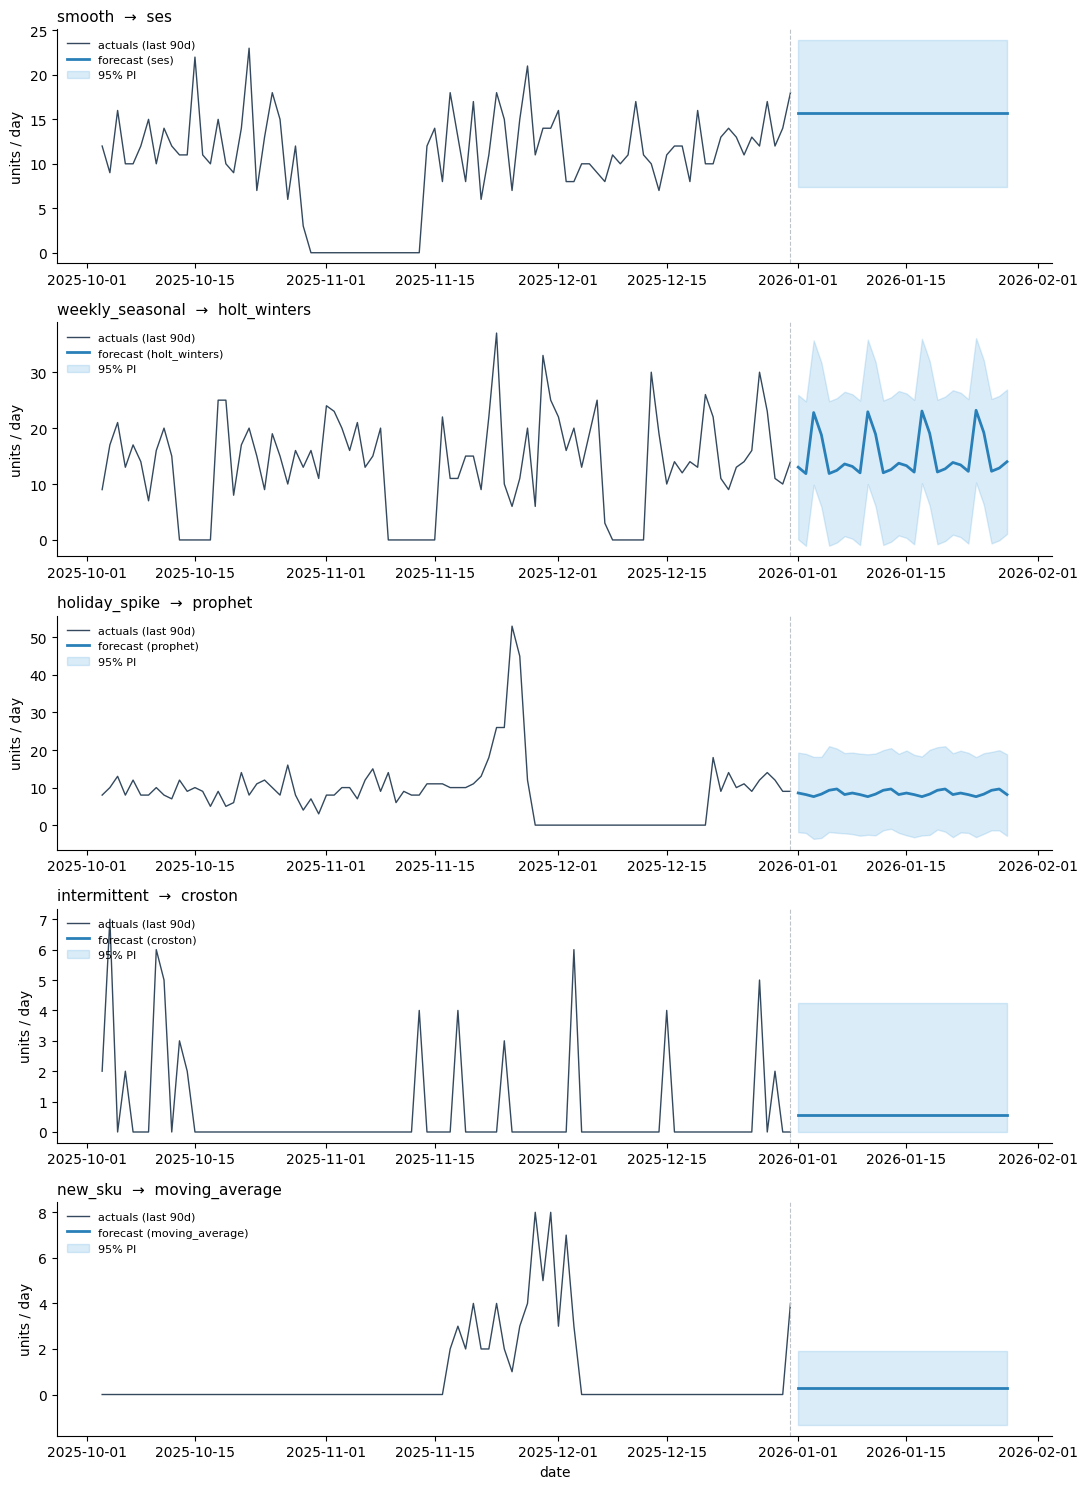

In [4]:
plt.style.use('default')
fig, axes = plt.subplots(len(results), 1, figsize=(11, 3.0 * len(results)), sharex=False)
if len(results) == 1:
    axes = [axes]

for ax, (pattern, r) in zip(axes, results.items()):
    history_window = 90
    h_dates = r['dates'][-history_window:]
    h_series = r['series'][-history_window:]
    f_dates = r['horizon_dates']

    ax.plot(h_dates, h_series, color='#34495e', linewidth=1.0, label='actuals (last 90d)')
    ax.plot(f_dates, r['forecast'], color='#2980b9', linewidth=2.0, label=f"forecast ({r['method_used']})")
    ax.fill_between(f_dates, r['lower_95'], r['upper_95'], color='#3498db', alpha=0.18, label='95% PI')
    ax.axvline(h_dates[-1], color='#bdc3c7', linestyle='--', linewidth=0.8)
    ax.set_title(f'{pattern}  →  {r["method_used"]}', loc='left', fontsize=11)
    ax.set_ylabel('units / day')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left', fontsize=8)
axes[-1].set_xlabel('date')
plt.tight_layout()
plt.show()


**How a counselor reads these.**

* **smooth** + SES — flat forecast, narrow band. Reorder math is predictable; safety stock from `msmt.resilience` will be tight.
* **weekly_seasonal** + Holt-Winters — the forecast bobs every 7 days to match the weekend lift. The PI tracks that pattern.
* **holiday_spike** + Prophet — Prophet picks up the seasonal cycle even when the next 28 days don't include a holiday peak.
* **intermittent** + Croston — the forecast is a low constant representing the smoothed average daily demand. The band is wide because most days are zero; that's a feature, not a bug.
* **new_sku** + moving_average — a humble trailing-mean forecast. Treat it as a placeholder until the SKU has 8+ weeks of history.

# Section 2 — Guardrails in action (Article 4)

A forecast that's correct on average can still be dangerous if it's *consistently* wrong, *suddenly* wrong, or being used to trigger an order quantity that's wildly out of line with recent run-rate. The five guardrails (all in `msmt.forecasting.guardrails`) are sanity checks that wrap a raw forecast before it drives a reorder.

| # | Guardrail | What it catches |
|---|---|---|
| 1 | drift_detection | several weeks of consistent over- or under-forecast |
| 2 | confidence_floor | PI so wide the forecast isn't actionable |
| 3 | regime_change_detection | recent actuals leaving the PI band repeatedly |
| 4 | reorder_cap | proposed order >> recent run-rate |
| 5 | graceful_degradation | what to do when the primary forecast fails |

### Simulate a regime change

We take a smooth SKU and inject a 4× demand surge over the last 7 days of its history — the kind of break a viral mention or a sudden listing change might cause. We then run `run_forecast` on the *pre-spike* history (so the forecaster doesn't see the spike) and run `run_guardrails` against the post-spike picture so the guardrails have a chance to detect the break.

In [5]:
smooth_sku = seller_df[seller_df['pattern'] == 'smooth']['sku_id'].iloc[0]
smooth_df = seller_df[seller_df['sku_id'] == smooth_sku].sort_values('date').reset_index(drop=True)

# Pre-spike: trim off the last 7 days so the forecaster sees only the
# original smooth history.
pre_spike = smooth_df.iloc[:-7].copy()
fc_pre = run_forecast(pre_spike, horizon=28)

# Post-spike: replace the last 7 actuals with a 4x surge.
post_spike = smooth_df.copy()
spike_idx = post_spike.index[-7:]
post_spike.loc[spike_idx, 'units_sold'] = (
    post_spike.loc[spike_idx, 'units_sold'].values * 4
).astype(int)

print(f'SKU: {smooth_sku}')
print(f'Pre-spike trailing-7 mean:  {smooth_df.iloc[-14:-7]["units_sold"].mean():.2f}')
print(f'Post-spike trailing-7 mean: {post_spike.iloc[-7:]["units_sold"].mean():.2f}')


SKU: SKU-SM-0001
Pre-spike trailing-7 mean:  12.00
Post-spike trailing-7 mean: 55.43


### Run all five guardrails

We pass the post-spike SKU history *and* a deliberately oversized proposed order quantity so the reorder-cap guardrail also has something to evaluate.

In [6]:
trailing_30 = post_spike['units_sold'].tail(30).mean()
proposed_qty = trailing_30 * 6  # 6x — should fire the cap

report = run_guardrails(post_spike, fc_pre, proposed_order_qty=proposed_qty)

print(f"SKU: {report['sku_id']}")
print(f"Any guardrail fired: {report['any_fired']}")
print(f"Overall: {report['overall_recommendation']}")
print()
for name, g in report['guardrails'].items():
    fired = g.get('fired')
    flag = 'FIRED' if fired else ' ok  '
    print(f"  [{flag}] {name:13s} {g.get('recommendation', '')}")


SKU: SKU-SM-0001
Any guardrail fired: True
Overall: 3 guardrails fired. Recommend pausing auto-reorder and reviewing manually.

  [ ok  ] drift         Forecast bias is within tolerance.
  [FIRED] confidence    Prediction interval is wider than the forecast itself; treat the point forecast as a rough estimate and pad safety stock rather than ordering to the forecast.
  [FIRED] regime        7 of the last 7 days fell outside the forecast band — refit the model on recent data before the next reorder.
  [FIRED] cap           Proposed order (127) is more than 3.0x the recent daily run-rate (21.2). Review manually before placing.
  [ ok  ] degradation   Primary forecast is OK; no fallback needed.


### Chart 2 — regime change visualization

Plot the pre-spike actuals, the spiked tail, the original forecast, and the trailing backtest band the guardrails compare against. The spike is the gap between the dashed line and the band.

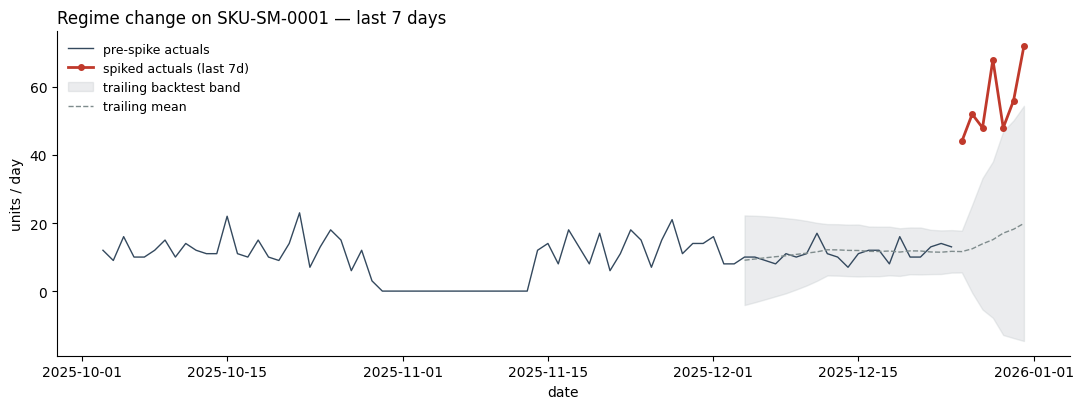

In [7]:
from msmt.forecasting.guardrails import _backtest_band

series_post = post_spike['units_sold'].astype(float).to_numpy()
dates_post = pd.DatetimeIndex(post_spike['date'])
actuals_bt, fc_bt, lo_bt, hi_bt = _backtest_band(series_post, window_days=28, lookback=28)
bt_dates = dates_post[-len(actuals_bt):]

fig, ax = plt.subplots(figsize=(11, 4.2))
history_window = 90
ax.plot(dates_post[-history_window:-7], series_post[-history_window:-7],
        color='#34495e', linewidth=1.0, label='pre-spike actuals')
ax.plot(dates_post[-7:], series_post[-7:], color='#c0392b', linewidth=2.0,
        marker='o', markersize=4, label='spiked actuals (last 7d)')
ax.fill_between(bt_dates, lo_bt, hi_bt, color='#bdc3c7', alpha=0.30, label='trailing backtest band')
ax.plot(bt_dates, fc_bt, color='#7f8c8d', linewidth=1.0, linestyle='--', label='trailing mean')
ax.set_title(f"Regime change on {smooth_sku} — last 7 days", loc='left')
ax.set_ylabel('units / day')
ax.set_xlabel('date')
ax.legend(frameon=False, loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### Chart 3 — guardrail status summary

A horizontal bar showing which guardrails fired, with the plain-English recommendation alongside. This is the chart that goes in front of a seller.

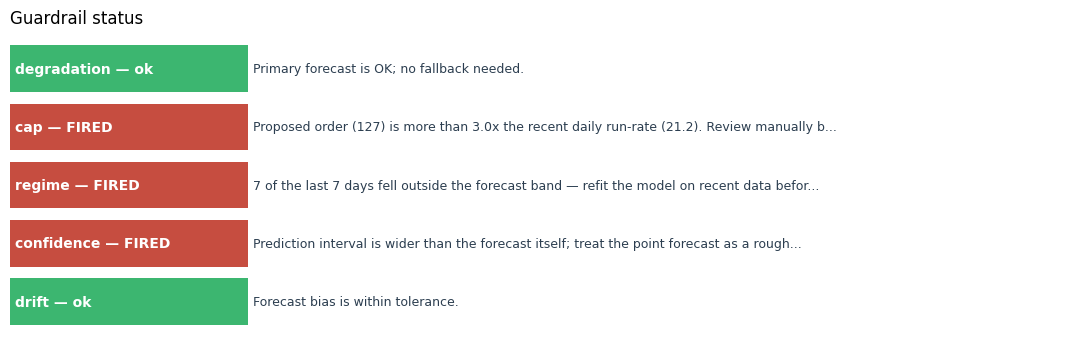

In [8]:
guard_order = ['drift', 'confidence', 'regime', 'cap', 'degradation']
labels = []
fired_flags = []
recs = []
for name in guard_order:
    g = report['guardrails'][name]
    labels.append(name)
    fired_flags.append(bool(g.get('fired')))
    recs.append(g.get('recommendation', ''))

fig, ax = plt.subplots(figsize=(11, 3.6))
y_pos = np.arange(len(labels))
colors = ['#c0392b' if f else '#27ae60' for f in fired_flags]
ax.barh(y_pos, [1] * len(labels), color=colors, alpha=0.9)
for i, (name, fired, rec) in enumerate(zip(labels, fired_flags, recs)):
    label = 'FIRED' if fired else 'ok'
    ax.text(0.02, i, f'{name} — {label}', va='center', color='white', fontsize=10, fontweight='bold')
    ax.text(1.02, i, rec[:90] + ('...' if len(rec) > 90 else ''), va='center', fontsize=9, color='#2c3e50')
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 4.5)
for s in ['top', 'right', 'bottom', 'left']:
    ax.spines[s].set_visible(False)
ax.set_title('Guardrail status', loc='left', fontsize=12)
plt.tight_layout()
plt.show()


### What to do when guardrails fire — counselor's decision table

| Pattern of fires | Likely meaning | What to do next |
|---|---|---|
| Only **confidence_floor** fires | Forecast is uncertain, but stable | Pad safety stock instead of ordering to the point forecast |
| Only **drift_detection** fires | Steady bias for 3+ weeks | Refit the model; check whether price, packaging, or competition changed |
| Only **regime_change_detection** fires | Recent break from normal | Hold off on auto-reorders until 1–2 weeks of new normal data are in |
| Only **reorder_cap** fires | Forecast may be fine, but the proposed quantity isn't | Manual review of the reorder math — expected this big a jump? |
| **drift + regime** fire together | Genuine regime change *and* the bias has been there a while | Treat as a structural shift; refit and re-classify the SKU |
| **confidence + regime** fire together | The model knows something is wrong | Use `graceful_degradation` to fall back to the trailing mean |
| 3+ guardrails fire | The forecast can't be trusted right now | Pause auto-reorder; re-run the full pipeline manually next week |

The point of the guardrails isn't to replace human judgment — it's to surface *which* judgment the human needs to make.

## Closing notes

* Everything in this notebook is reproducible from the `seed=42` at the top — change the seed and re-run to see how the picture shifts on a different synthetic catalog.
* `run_forecast` and `run_guardrails` work directly on real seller-portal exports as long as the data has the canonical columns (`date`, `sku_id`, `units_sold`, `lead_time_days`, `stock_on_hand`).
* If Prophet is unavailable on your machine (older Python, restricted environments), `prophet_forecast` falls back to a pure-numpy additive model — the pipeline keeps working without code changes.
* The guardrail thresholds (3 weeks of drift, 50% PI ratio, 5-of-7 out-of-band days, 3× run-rate cap) are practitioner defaults. Tune them for your catalog: a fast-moving, low-margin SKU should probably trip earlier than a slow-moving high-margin one.